In [1]:

!pip install -q diffusers transformers accelerate safetensors

### Import Libraries

In [2]:
import torch
from diffusers import StableDiffusionPipeline
from pathlib import Path

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("Device:", device)
print("Dtype:", dtype)

Device: cuda
Dtype: torch.float16


### Download Trained Model Weights

In [4]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
)

pipe = pipe.to(device)

print("Model loaded successfully")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /home/tmedi/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /home/tmedi/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


### Load Model Weights inot Generation Model

In [6]:
def generate_images(category, num_images=4):
    
    prompt = f"a high quality photo of a {category}"
    
    images = pipe(
        [prompt] * num_images,
        num_inference_steps=25
    ).images
    
    return images

### Generate different categories as you imagine 

  0%|          | 0/25 [00:00<?, ?it/s]

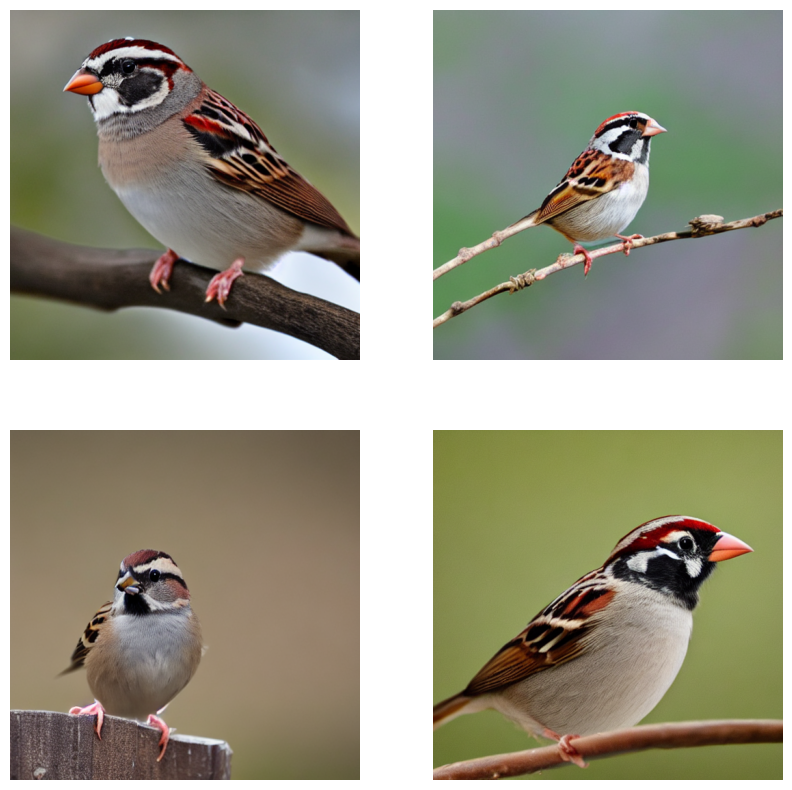

In [7]:
import matplotlib.pyplot as plt

category = "sparrow"

images = generate_images(category, num_images=4)

plt.figure(figsize=(10,10))

for i, img in enumerate(images):
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

### Save Generated Images

In [8]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

for i, img in enumerate(images):
    img.save(output_dir / f"{category}_{i}.png")

print("Saved images to outputs/")

Saved images to outputs/


### Now Lets Generate with Prompts (Sentences with Details)

In [9]:
def generate_from_prompt(prompt, num_images=4):
    
    images = pipe(
        [prompt] * num_images,
        num_inference_steps=25
    ).images
    
    return images

  0%|          | 0/25 [00:00<?, ?it/s]

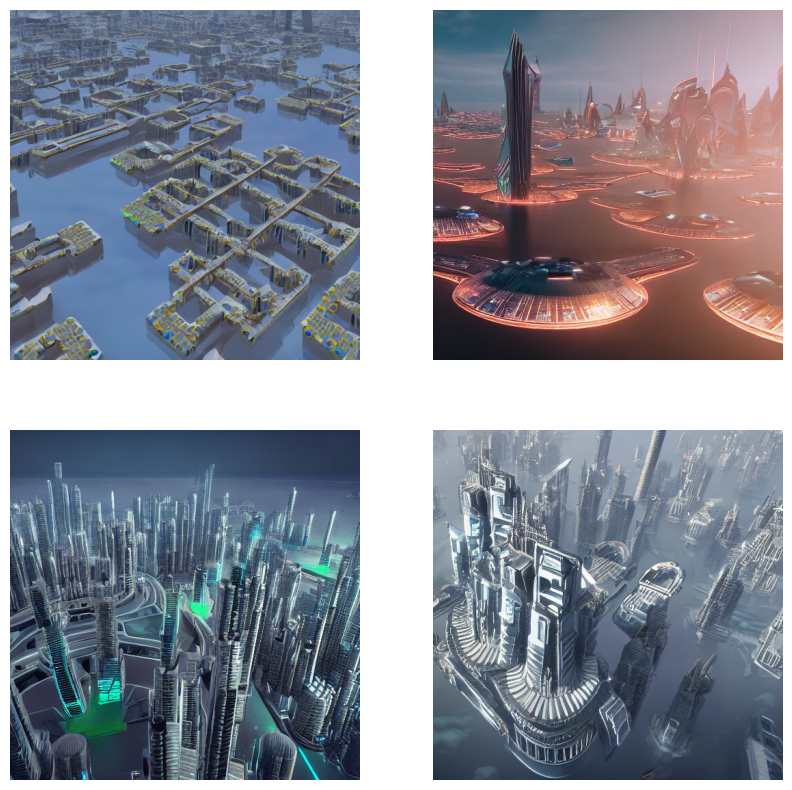

In [10]:
prompt = "A futuristic city floating in the sky, ultra realistic, 4k"

images = generate_from_prompt(prompt, num_images=4)
# Cell 10: Show images

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i, img in enumerate(images):
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

### Lets try different Styles of Generation using prompts

In [11]:
def generate_with_style(prompt, style, num_images=4):
    
    styled_prompt = f"{prompt}, {style}"
    
    images = pipe(
        [styled_prompt] * num_images,
        num_inference_steps=25
    ).images
    
    return images

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

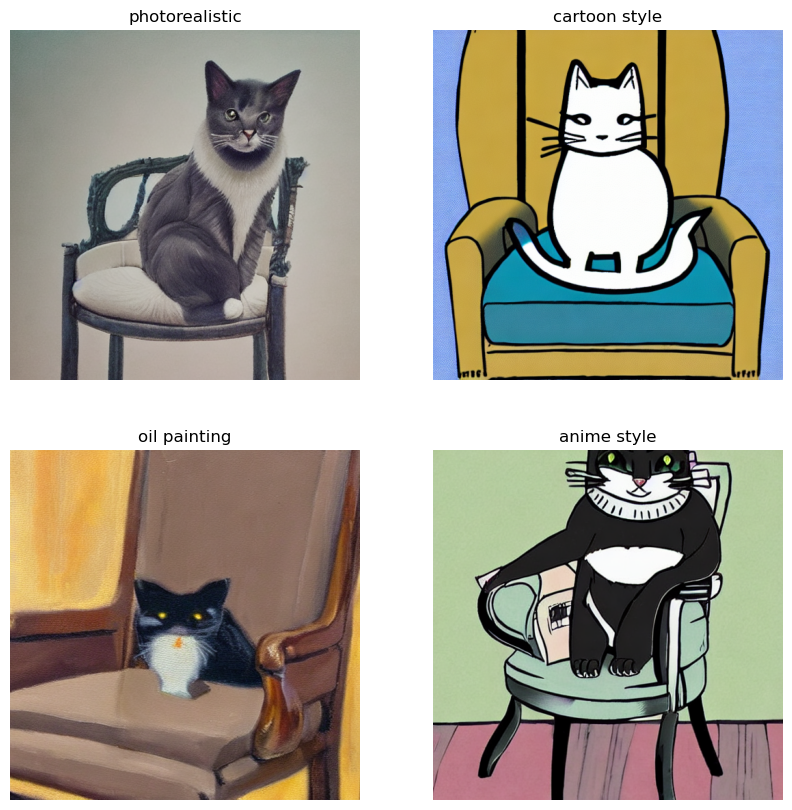

In [12]:
prompt = "a cat sitting on a chair"

styles = [
    "photorealistic",
    "cartoon style",
    "oil painting",
    "anime style"
]

images = []

for style in styles:
    img = generate_with_style(prompt, style, num_images=1)[0]
    images.append(img)

# Cell 13: Show style comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i, img in enumerate(images):
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(styles[i])
    plt.axis("off")

plt.show()

# Thank you

Hope you had fun creating